<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>

<center><b><h1>Lab - 10 </b></center>
<center><b><h5>K-means, K-Medoids</b></center>
<pre>    

# Step 1: Import Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Step 2: Load the Dataset
Load Given dataset -  StudentsPerformance.csv

In [3]:
df = pd.read_csv("StudentsPerformance.csv")

In [4]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


# Step 3: Data Overview
In this step, we examine the dataset structure, summary statistics, and check for missing values.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [7]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


# Step 4: Display PairPlot

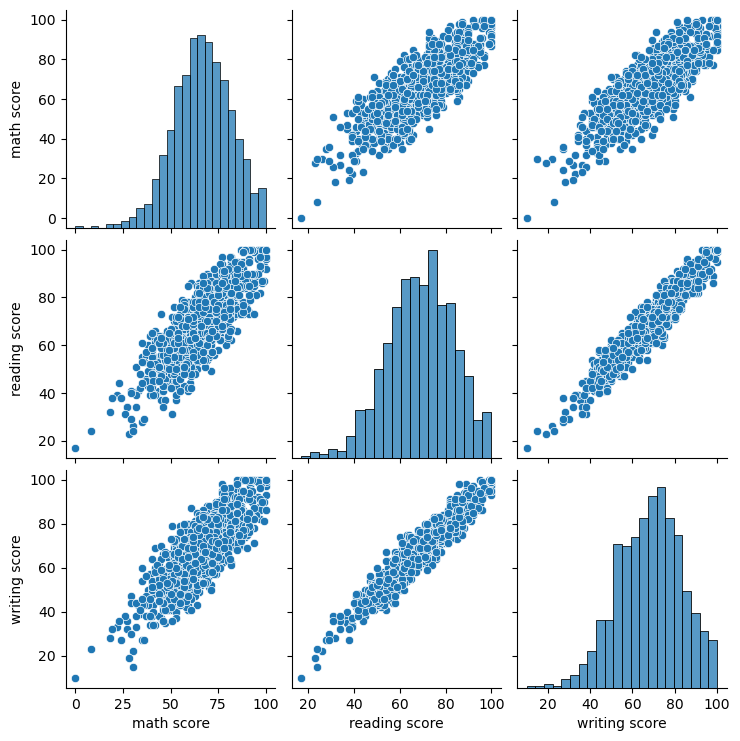

In [9]:
sns.pairplot(df)
plt.show()

# Step 5: Correlation heatmap

In [11]:
df.corr(numeric_only=True)

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


<Axes: >

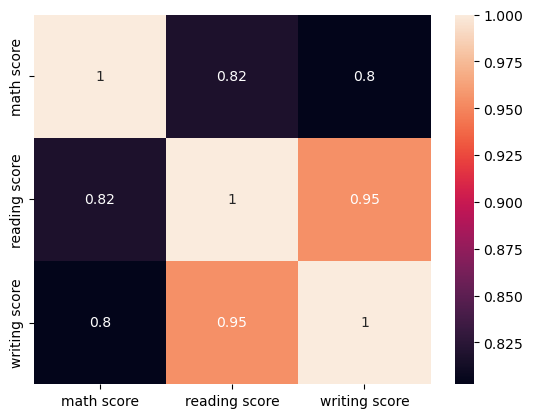

In [12]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

# Step 6: Distribution of numerical features

<Axes: xlabel='math score', ylabel='Count'>

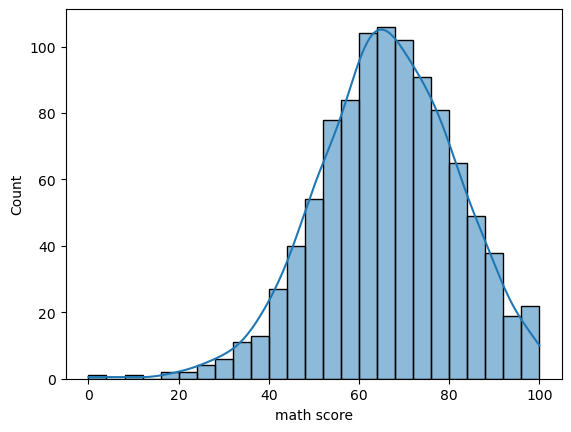

In [14]:
sns.histplot(df['math score'], kde=True)

<Axes: xlabel='reading score', ylabel='Count'>

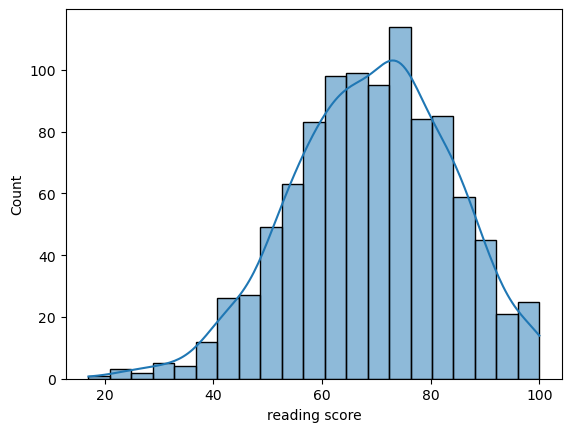

In [15]:
sns.histplot(df['reading score'], kde=True)

<Axes: xlabel='writing score', ylabel='Count'>

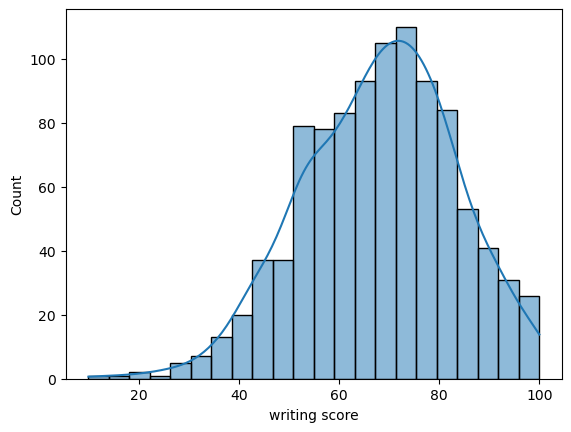

In [16]:
sns.histplot(df['writing score'], kde=True)

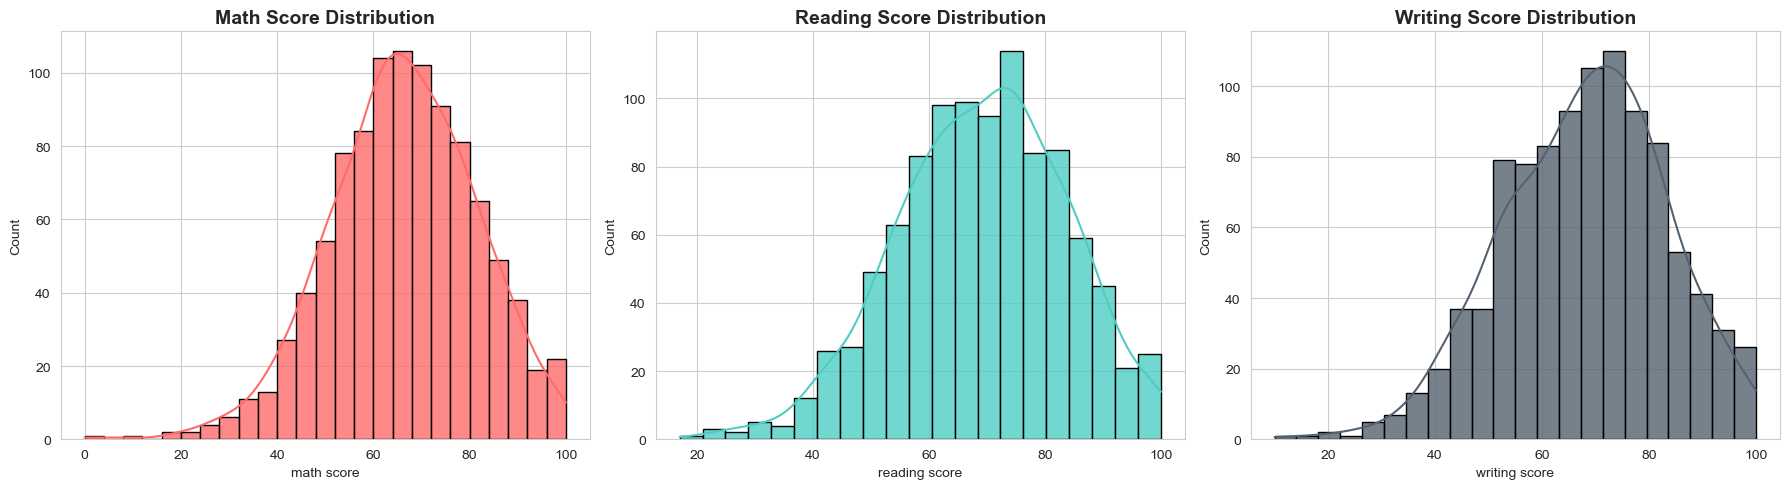

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set_style("whitegrid")

plt.figure(figsize=(18,5))

# 1️⃣ Math Score
plt.subplot(1, 3, 1)
sns.histplot(df['math score'], 
             kde=True, 
             color='#FF6B6B',   # Coral Red
             edgecolor='black',
             alpha=0.8)
plt.title("Math Score Distribution", fontsize=14, fontweight='bold')

# 2️⃣ Reading Score
plt.subplot(1, 3, 2)
sns.histplot(df['reading score'], 
             kde=True, 
             color='#4ECDC4',   # Teal
             edgecolor='black',
             alpha=0.8)
plt.title("Reading Score Distribution", fontsize=14, fontweight='bold')

# 3️⃣ Writing Score
plt.subplot(1, 3, 3)
sns.histplot(df['writing score'], 
             kde=True, 
             color='#556270',   # Elegant Blue-Grey
             edgecolor='black',
             alpha=0.8)
plt.title("Writing Score Distribution", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


# Step 7: Apply StandardScaler

In [19]:
from sklearn.preprocessing import StandardScaler


In [20]:
X = df[['math score', 'reading score', 'writing score']]


In [21]:
scaler = StandardScaler()


In [22]:
X_scaled = scaler.fit_transform(X)


In [23]:
import pandas as pd

X_scaled = pd.DataFrame(X_scaled, 
                        columns=['math score', 'reading score', 'writing score'])

print(X_scaled.head(10))


   math score  reading score  writing score
0    0.390024       0.193999       0.391492
1    0.192076       1.427476       1.313269
2    1.577711       1.770109       1.642475
3   -1.259543      -0.833899      -1.583744
4    0.653954       0.605158       0.457333
5    0.324041       0.947790       0.654857
6    1.445746       1.770109       1.576634
7   -1.721422      -1.793271      -1.912950
8   -0.137838      -0.354214      -0.069397
9   -1.853387      -0.628320      -1.188697


In [24]:
df[['math_scaled', 'reading_scaled', 'writing_scaled']] = X_scaled


In [25]:
X = df[['reading score', 'writing score']]
y = df['math score']



In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [27]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df[['math score', 
                                       'reading score', 
                                       'writing score']])


# Step 8: Elbow method to find optimal k

In [75]:
from sklearn.cluster import KMeans

C:\Users\MONIL KANSAGRA\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\MONIL KANSAGRA\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\MONIL KANSAGRA\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\MONIL KANSAGRA\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is k

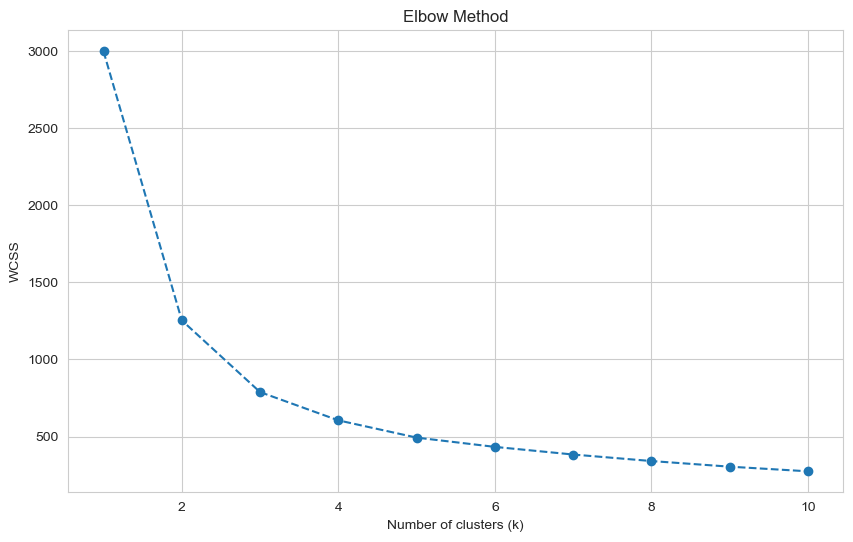

[3000.0, 1253.8571144508817, 788.3656838915331, 604.921239013084, 492.95066485513524, 432.715836247986, 383.1368293631918, 340.8342066300557, 304.3486391178841, 274.2000202706408]


In [77]:
wcss = []
k_range = range(1,11)

for k in  k_range:
    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10,6))
plt.plot(k_range,wcss,marker='o',linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.show()

print(wcss)

# Step 9:Based on the elbow plot, choose an appropriate k value (e.g., k=3)

In [81]:
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_scaled)



C:\Users\MONIL KANSAGRA\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


# Step 10: Print Cluster Center

In [83]:
print("Cluster Centers:\n", kmeans.cluster_centers_)

Cluster Centers:
 [[-0.04951336 -0.04870596 -0.01529686]
 [-1.18720058 -1.26762535 -1.28838441]
 [ 1.03099793  1.09485536  1.06358515]]


# Step 11: Plot Cluster

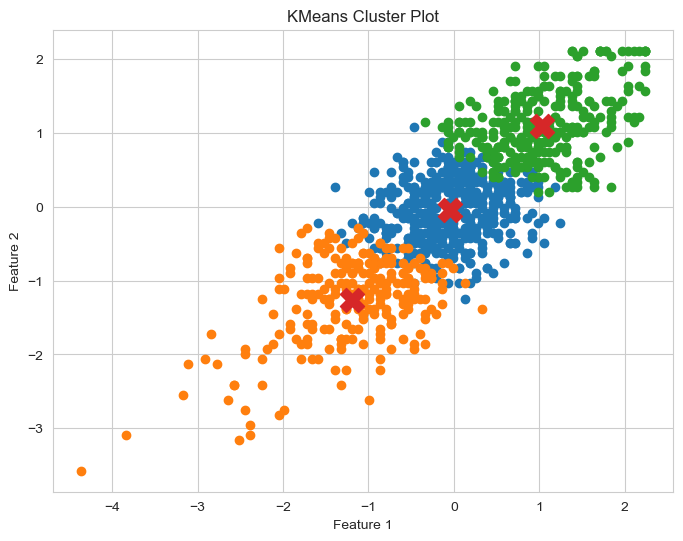

In [93]:
import matplotlib.pyplot as plt
import numpy as np

X_array = np.array(X_scaled)

plt.figure(figsize=(8,6))

for i in range(kmeans.n_clusters):
    plt.scatter(
        X_array[y_kmeans == i, 0],
        X_array[y_kmeans == i, 1]
    )


plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=300,
    marker='X'
)

plt.title("KMeans Cluster Plot")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


# Step 12:Analyze clusters 

In [95]:
df['Cluster'] = y_kmeans


In [97]:
print(df['Cluster'].value_counts())


Cluster
0    443
2    308
1    249
Name: count, dtype: int64


# Step 13: Perform K-Medoids

In [101]:
!pip install scikit-learn-extra

     ---------------------------------------- 0.0/819.0 kB ? eta -:--:--
     ------------------------------------- 819.0/819.0 kB 18.0 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Failed to build scikit-learn-extra


  error: subprocess-exited-with-error
  
  exit code: 1
  
  [77 lines of output]
  C:\Users\MONIL KANSAGRA\AppData\Local\Temp\pip-build-env-i7getimn\overlay\Lib\site-packages\setuptools\dist.py:599: SetuptoolsDeprecationWarning: Invalid dash-separated key 'description-file' in 'metadata' (setup.cfg), please use the underscore name 'description_file' instead.
  !!
  
          ********************************************************************************
          Usage of dash-separated 'description-file' will not be supported in future
          versions. Please use the underscore name 'description_file' instead.
          (Affected: scikit-learn-extra).
  
          Available configuration options are listed in:
          https://setuptools.pypa.io/en/latest/userguide/declarative_config.html
  
          By 2026-Mar-03, you need to update your project and remove deprecated calls
          or your builds will no longer be supported.
  
          See https://github.com/pypa/setuptoo

In [99]:
from sklearn_extra.cluster import KMedoids

ModuleNotFoundError: No module named 'sklearn_extra'

# Step:14 Comparison of K-means and K-medoids Clusters

# Step: 15 | USE KMEAN++
